In [1]:
from pydol.photometry.scripts.gloess import gloess
from pydol.photometry.scripts.catalog_filter import box, ellipse, polygon
from pydol.photometry.scripts.cmdtools import gen_CMD, gen_CMD_ycut, gen_CMD_xcut, running_avg

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table, join, hstack, vstack
from astropy.visualization import simple_norm
from astropy.coordinates import angular_separation, SkyCoord
from astropy.modeling import models, fitting
from astropy.stats import sigma_clipped_stats
import astropy.units as u
from astropy.stats.biweight import biweight_location, biweight_midvariance,biweight_scale

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoLocator, AutoMinorLocator)
from matplotlib.colors import ListedColormap

import json
import shapely

In [2]:
Av_dict = { 
            'f275w': 2.02499,
            'f336w': 1.67536,
            'f435w': 1.33879,
            'f555w': 1.03065,
            'f814w': 0.59696,
    
            'f090w': 0.583,
            'f115w': 0.419,
            'f150w': 0.287,
            'f200w': 0.195,
            'f335m': 0.103,
    
            'f438w': 1.34148,
            'f606w': 0.90941,
            'f814w': 0.59845
          }


In [4]:
df_cmd_jwst = pd.read_csv("../data/isochrones_master/cmd_jwst_master.csv")
df_cmd_acs  = pd.read_csv("../data/isochrones_master/cmd_hst_acs.csv")

/home/avinash/miniconda3/envs/jwst/lib/python3.13/site-packages/pydol/photometry/scripts/cmdtools.py:437: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/avinash/miniconda3/envs/jwst/lib/python3.13/site-packages/pydol/photometry/scripts/cmdtools.py:437: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/avinash/miniconda3/envs/jwst/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/avinash/miniconda3/envs/jwst/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


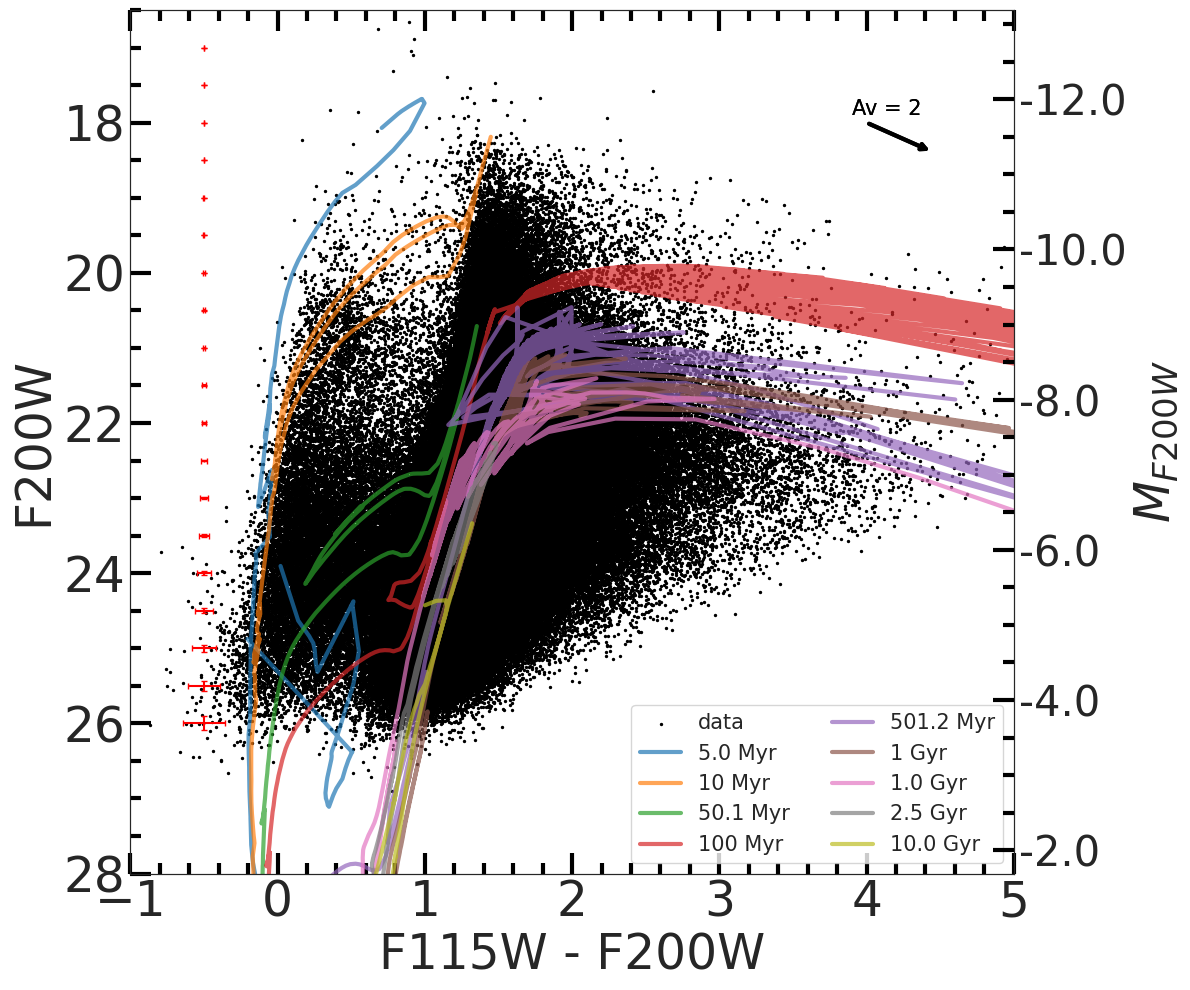

In [4]:
tab = Table.read('../photometry/m51/f115w_f150w_f200w_photometry.fits')

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f200w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-1, 5], 
              'ylims': [16.5, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.7, 8, 8.7,9]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]

fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': True},
                      fig=fig, ax=ax)

#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')

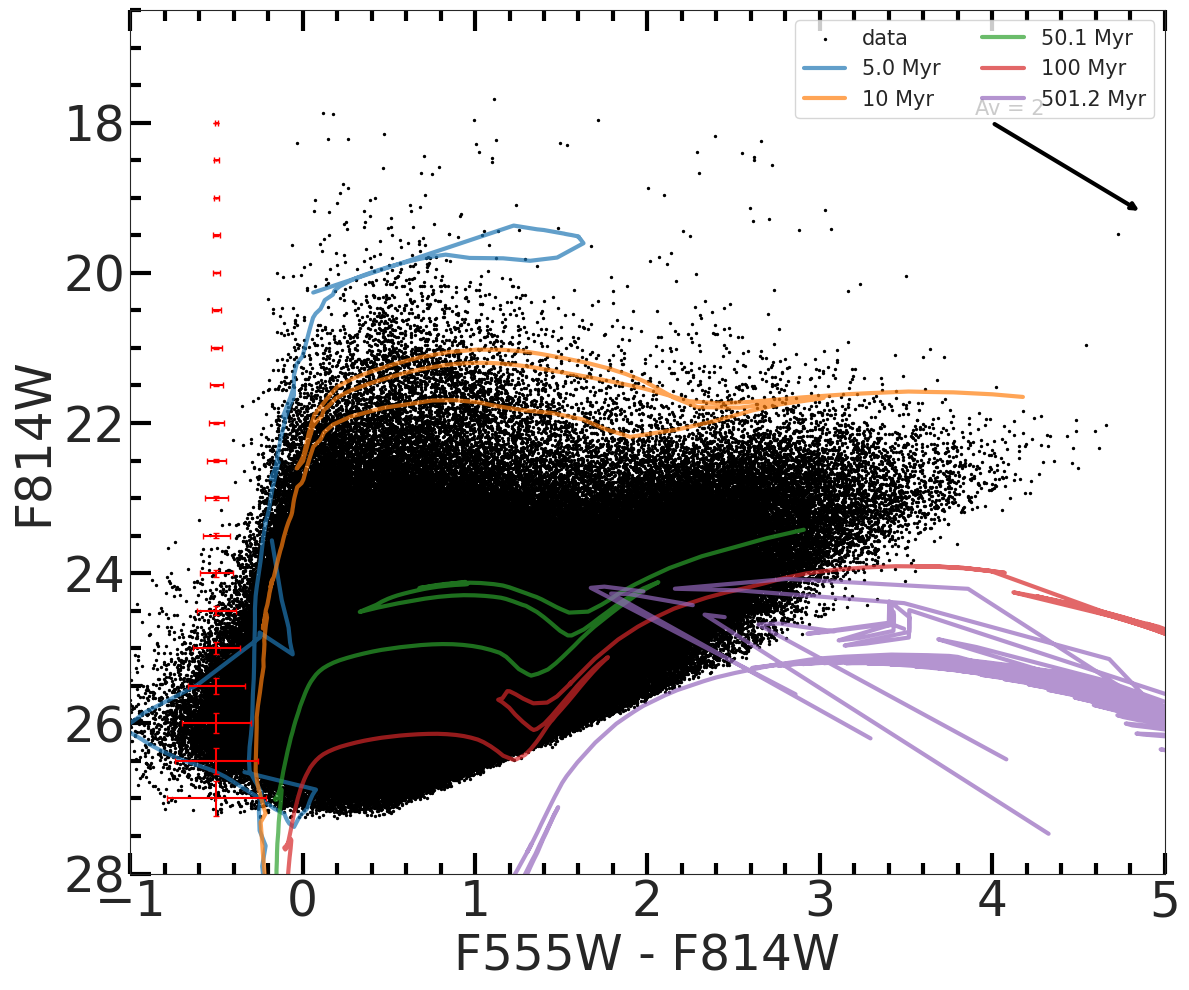

In [11]:
tab = Table.read('../photometry/m51/f555w_f814w_photometry.fits')

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f555w',
           'filt2':'f814w',
           'filt3':'f814w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-1, 5], 
              'ylims': [16.5, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.7, 8, 8.7]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_acs,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)


#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')

(202.37199784979177, 202.562792177981, 47.121513321186356, 47.30613545653308)

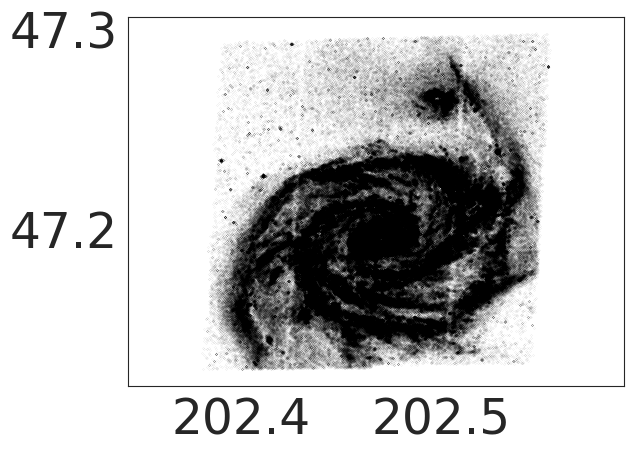

In [10]:
x = tab1['ra']
y = tab1['dec']

plt.scatter(x,y, s=0.001, color='black')
plt.axis('equal')

In [5]:
df_cmd_acs = pd.read_csv("../data/isochrones_master/cmd_hst_acs.csv")

In [6]:
cols = 'ID F115W eF115W F115W-F200W errJK F555W eF555W F435W-F555W eBV F555W-F814W eVI ra dec'.split()

In [237]:
df = pd.read_csv('../photometry/m51/m51_rsg_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])
tab_rsg = Table.from_pandas(df)
tab_rsg['star_class'] = 'RSG'

df = pd.read_csv('../photometry/m51/m51_bsg_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])
tab_bsg = Table.from_pandas(df)
tab_bsg['star_class'] = 'BSG'

df = pd.read_csv('../photometry/m51/m51_ysg_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])
tab_ysg = Table.from_pandas(df)
tab_ysg['star_class'] = 'YSG'

df = pd.read_csv('../photometry/m51/m51_yms_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])

tab_yms = Table.from_pandas(df)
tab_yms['star_class'] = 'YMS'

df = pd.read_csv('../photometry/m51/m51_rrsg_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])

tab_rrsg = Table.from_pandas(df)
tab_rrsg['star_class'] = 'RRSG'

df = pd.read_csv('../photometry/m51/m51_agb_all_cmd.dat', sep=' ', header=None, names=cols)
for col in cols:
    df.loc[df[col] == 'INDEF', col] = np.nan
    df[col] = np.float64(df[col])

tab_agb = Table.from_pandas(df)
tab_agb['star_class'] = 'AGB'

tab_main = vstack([tab_rsg, tab_bsg, tab_ysg, tab_yms,tab_rrsg, tab_agb])

In [238]:
tab_main['mag_vega_F115W'] = tab_main['F115W']
tab_main['mag_err_F115W']  = tab_main['eF115W']

tab_main['mag_vega_F200W'] = tab_main['F115W'] - tab_main['F115W-F200W']
tab_main['mag_err_F200W']  = np.sqrt(tab_main['errJK']**2 - tab_main['eF115W']**2)

tab_main['mag_vega_F435W'] = tab_main['F435W-F555W'] + tab_main['F555W']
tab_main['mag_err_F435W'] = np.sqrt(tab_main['eBV']**2 - tab_main['eF555W']**2)

tab_main['mag_vega_F555W'] = tab_main['F555W']
tab_main['mag_err_F555W'] = tab_main['eF555W']

tab_main['mag_vega_F814W'] = tab_main['F555W'] - tab_main['F555W-F814W']
tab_main['mag_err_F814W'] = np.sqrt(tab_main['eVI']**2 - tab_main['eF555W']**2)

/tmp/ipykernel_1520/2993663136.py:8: RuntimeWarning: invalid value encountered in sqrt
  tab_main['mag_err_F435W'] = np.sqrt(tab_main['eBV']**2 - tab_main['eF555W']**2)


In [239]:
tab_sub = tab_main[tab_main['mag_vega_F555W']<=24]

nn_counts = []
for row in tab_sub:
    r = angular_separation(row['ra']*u.deg, row['dec']*u.deg, 
                           tab_sub['ra'].value*u.deg, tab_sub['dec'].value*u.deg).to(u.arcsec).value
    r_in = r[(r<=1) & (r>0)]
    nn_counts.append(len(r_in))

In [240]:
len(tab_sub), len(tab_main)

(11353, 23007)

In [10]:
tab_sub['NN_count'] = nn_counts
tab_sub_filt = tab_sub[tab_sub['NN_count']==0]

In [11]:
AGB_region = np.array([[ 1.40, 22.38],
       [ 1.6, 21.],
       [ 3.48, 23.21]])

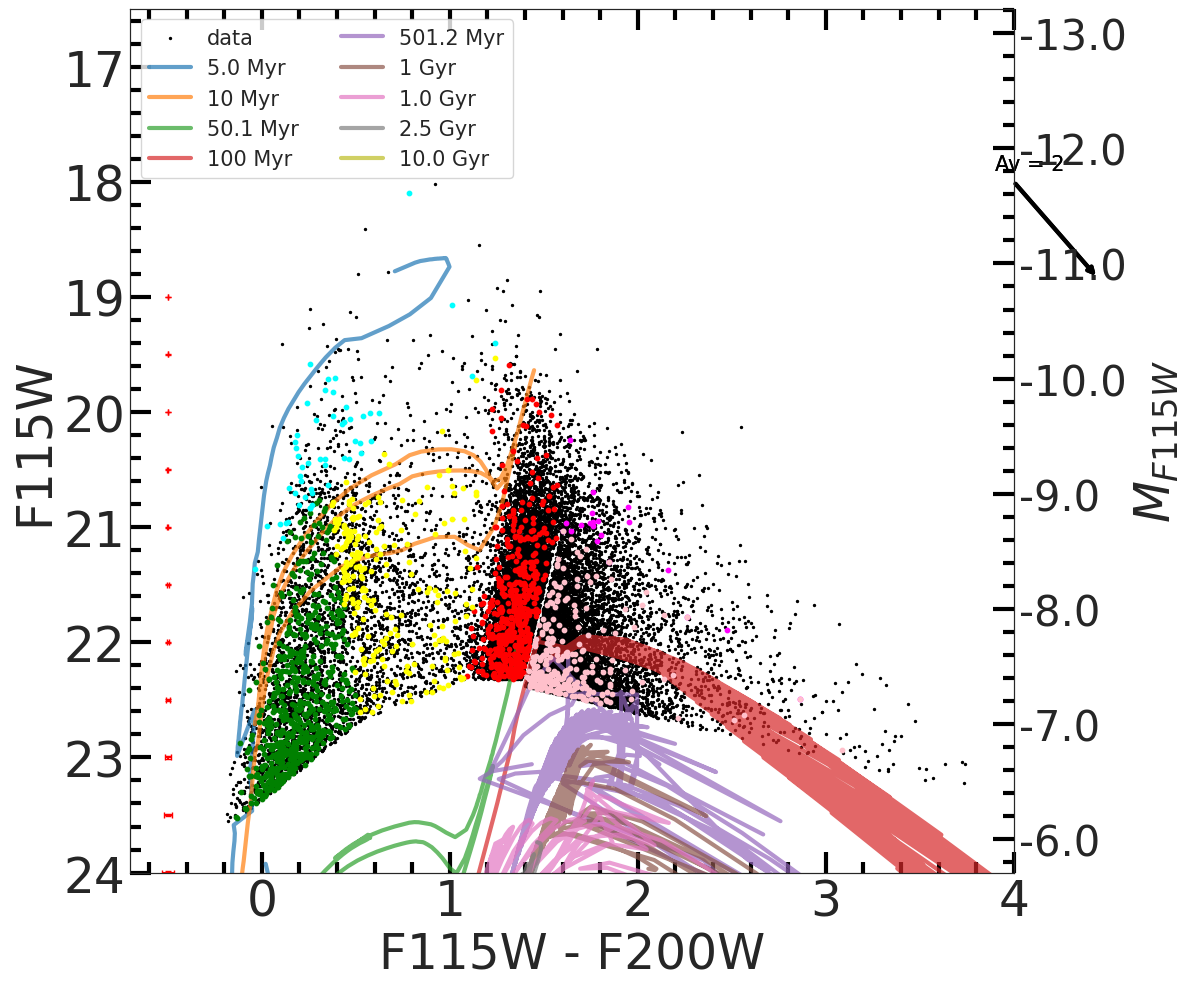

In [12]:
tab = tab_main

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f115w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-0.7, 4], 
              'ylims': [16.5, 24]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.7, 8, 8.7,9]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]

fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': True},
                      fig=fig, ax=ax)

# RSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='RSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='red' ,zorder=200)

#BSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='BSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='green' ,zorder=200)

#YSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='YSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='yellow' ,zorder=200)

#YMS
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='YMS']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='cyan' ,zorder=200)

#RRSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='RRSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='magenta' ,zorder=200)

#AGB
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='AGB']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=10, color='pink' ,zorder=200)
#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')

In [13]:
tab_sub_filt.to_pandas().groupby('star_class').count()['ID']

star_class
AGB     261
BSG     612
RRSG     20
RSG     472
YMS      52
YSG     220
Name: ID, dtype: int64

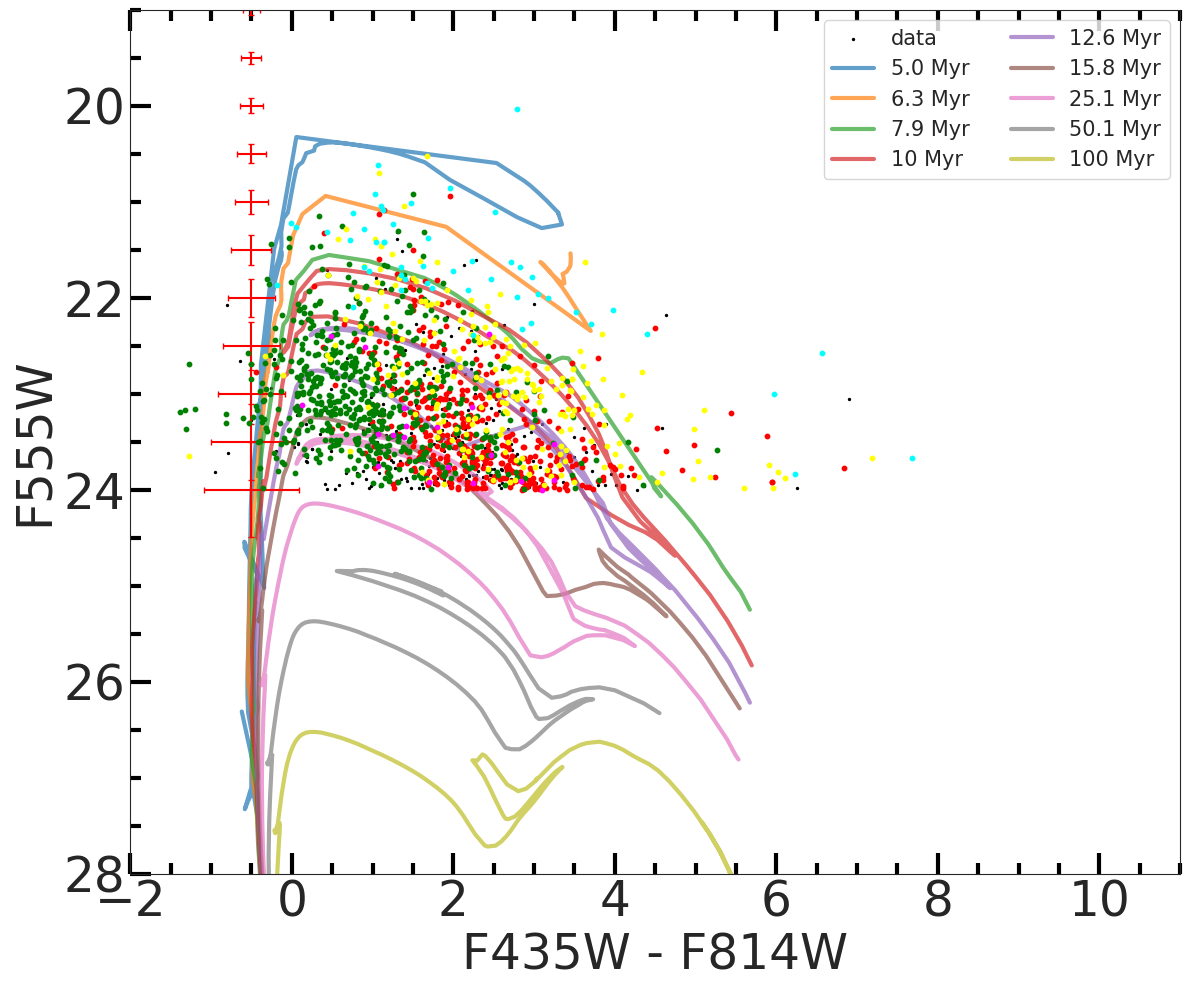

In [14]:
tab = tab_sub_filt

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f435w',
           'filt2':'f814w',
           'filt3':'f555w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-2, 11], 
              'ylims': [19, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 6.8, 6.9, 7, 7.1, 7.2, 7.4, 7.7, 8],
                   'iso_mask_lim' : 100}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':1}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_acs,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

# RSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='RSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=10, color='red' ,zorder=200)

#BSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='BSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=10, color='green' ,zorder=200)

#YSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='YSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=10, color='yellow' ,zorder=200)

#YMS
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='YMS']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=10, color='cyan' ,zorder=200)

#RRSG
tab_temp = tab_sub_filt[tab_sub_filt['star_class']=='RRSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=10, color='magenta' ,zorder=200)

In [15]:
text = """# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
icrs\n"""

colors = ['red', 'green', 'yellow', 'cyan','magenta','white']
for n,i in enumerate(['RSG', 'BSG', 'YSG', 'YMS','RRSG','AGB']):
    
    with open(f'../catalogs/m51/{i}.reg','w') as f:
        f.writelines(text)
        df = tab_sub_filt[tab_sub_filt['star_class']==i]
        for row in df:
            r = (24- row['mag_vega_F555W'])*0.25
            ra = row['ra']
            dec = row['dec']
            f.writelines(
                f'circle({ra:.7f},{dec:.7f},{r:.2f}") # text={{{int(row["ID"])}}} color={{{colors[n]}}}\n'
            )

In [ ]:
text = """# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
icrs\n"""

colors = ['red', 'green', 'yellow', 'cyan','magenta','white']
for n,i in enumerate(['RSG', 'BSG', 'YSG', 'YMS','RRSG','AGB']):
    with open(f'../catalogs/m51/{i}_rect.reg','w') as f:
        f.writelines(text)
        df = tab_sub_filt[tab_sub_filt['star_class']==i]
        for row in df:
            r = (24- row['mag_vega_F555W'])*0.25
            ra = row['ra']
            dec = row['dec']
            f.writelines(f"""box({ra:0.7f},{dec:0.7f},1.2", 3",0) # text={{{int(row["ID"])}}}\n color={{{colors[n]}}}""")

In [224]:
with open('../photometry/m51/m51_2026A_EW1_selected.reg') as f:
    dat = f.readlines()

ras = []
decs = []
texts = []
GC_flag = []
for n, d in enumerate(dat):
    if n > 2 and '#' not in d[0]:
        reg = d.split(',')
        reg[0] = reg[0].replace('circle','box')
        reg[2] = '1.2",3",90'+reg[2][6:] 
        ras.append(float(reg[0][4:]))
        decs.append(float(reg[1]))
        texts.append(reg[2].split('{')[-1].split('}')[0])
        reg = ','.join(reg)
        dat[n] = reg

        if 'M51' in reg:
            GC_flag.append(True)
        else:
            GC_flag.append(False)
            
with open('../photometry/m51/m51_2026A_EW1_selected_slits.reg','w') as f:
    f.writelines(dat)

tab_EW1 = Table([ras,decs,texts, GC_flag], names=['ra','dec', 'text','GC_flag'])

In [225]:
with open('../photometry/m51/m51_2026A_EW2_selected.reg') as f:
    dat = f.readlines()

ras = []
decs = []
texts = []
GC_flag = []
for n, d in enumerate(dat):
    if n > 2 and '#' not in d[0]:
        reg = d.split(',')
        reg[0] = reg[0].replace('circle','box')
        reg[2] = '1.2",3",90'+reg[2][6:] 
        ras.append(float(reg[0][4:]))
        decs.append(float(reg[1]))
        texts.append(reg[2].split('{')[-1].split('}')[0])
        reg = ','.join(reg)
        dat[n] = reg
        if 'M51' in reg:
            GC_flag.append(True)
        else:
            GC_flag.append(False)
with open('../photometry/m51/m51_2026A_EW2_selected_slits.reg','w') as f:
    f.writelines(dat)

tab_EW2 = Table([ras,decs,texts, GC_flag], names=['ra','dec', 'text','GC_flag'])

In [226]:
tab_sel = vstack([tab_EW1, tab_EW2])

In [241]:
coords_filts = SkyCoord(tab_main['ra'], tab_main['dec'], unit='deg')
coords_sel = SkyCoord(tab_sel['ra'], tab_sel['dec'], unit='deg')

In [242]:
ids, d2d, d3d = coords_filts.match_to_catalog_sky(coords_sel)
d2d = d2d.to(u.arcsec).value

In [243]:
tab_main['d'] = d2d
tab_main['text'] = tab_sel['text'][ids]
tab_main['GC_flag'] = tab_sel['GC_flag'][ids]

In [244]:
tab_sub_sel = tab_sub_filt[tab_sub_filt['d']<=0.1]

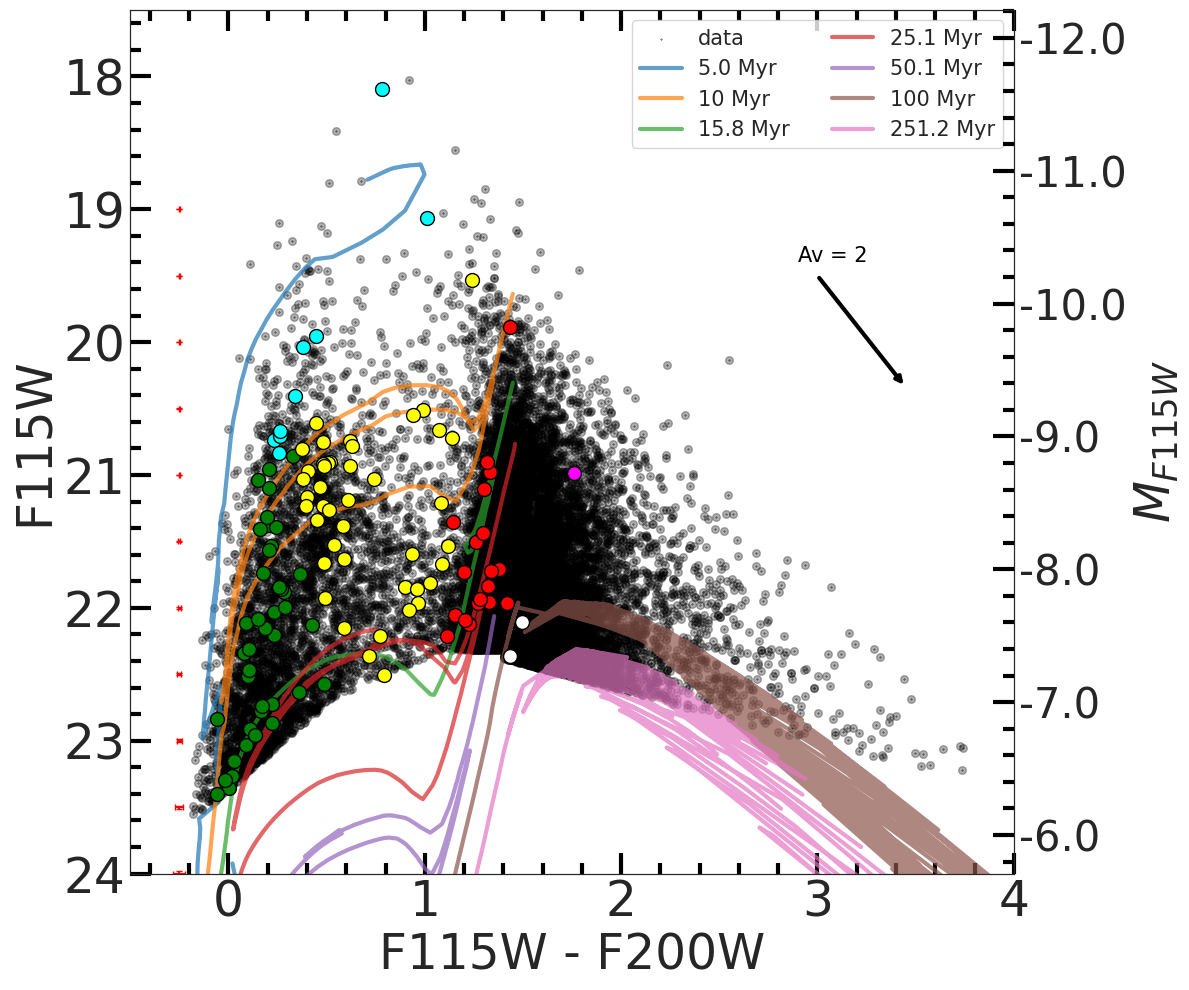

In [247]:
tab = tab_main

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f115w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 3,
              'Av_y': 19.5,
              'Av_' : 2}

axis_limits= {'xlims': [-0.5, 4], 
              'ylims': [17.5, 24]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.2, 7.4, 7.7, 8, 8.4]}

error_settings = {'ref_xpos': -0.25,
                  'mag_err_lim':0.2}

plot_settings = {'s':0.1, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]


# RSG
tab_temp = tab_main
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=30, color='black' ,zorder=0, alpha=0.3)

# RSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='RSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='red' ,zorder=200, edgecolor='black')

#BSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='BSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='green' ,zorder=200, edgecolor='black')

#YSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='YSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='yellow' ,zorder=200, edgecolor='black')

#YMS
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='YMS']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='cyan' ,zorder=200, edgecolor='black')

#RRSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='RRSG']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='magenta' ,zorder=200, edgecolor='black')

#AGB
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='AGB']
x = tab_temp['mag_vega_F115W'] - tab_temp['mag_vega_F200W']
y = tab_temp['mag_vega_F115W']

ax.scatter(x,y, s=100, color='white' ,zorder=200, edgecolor='black')
#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')

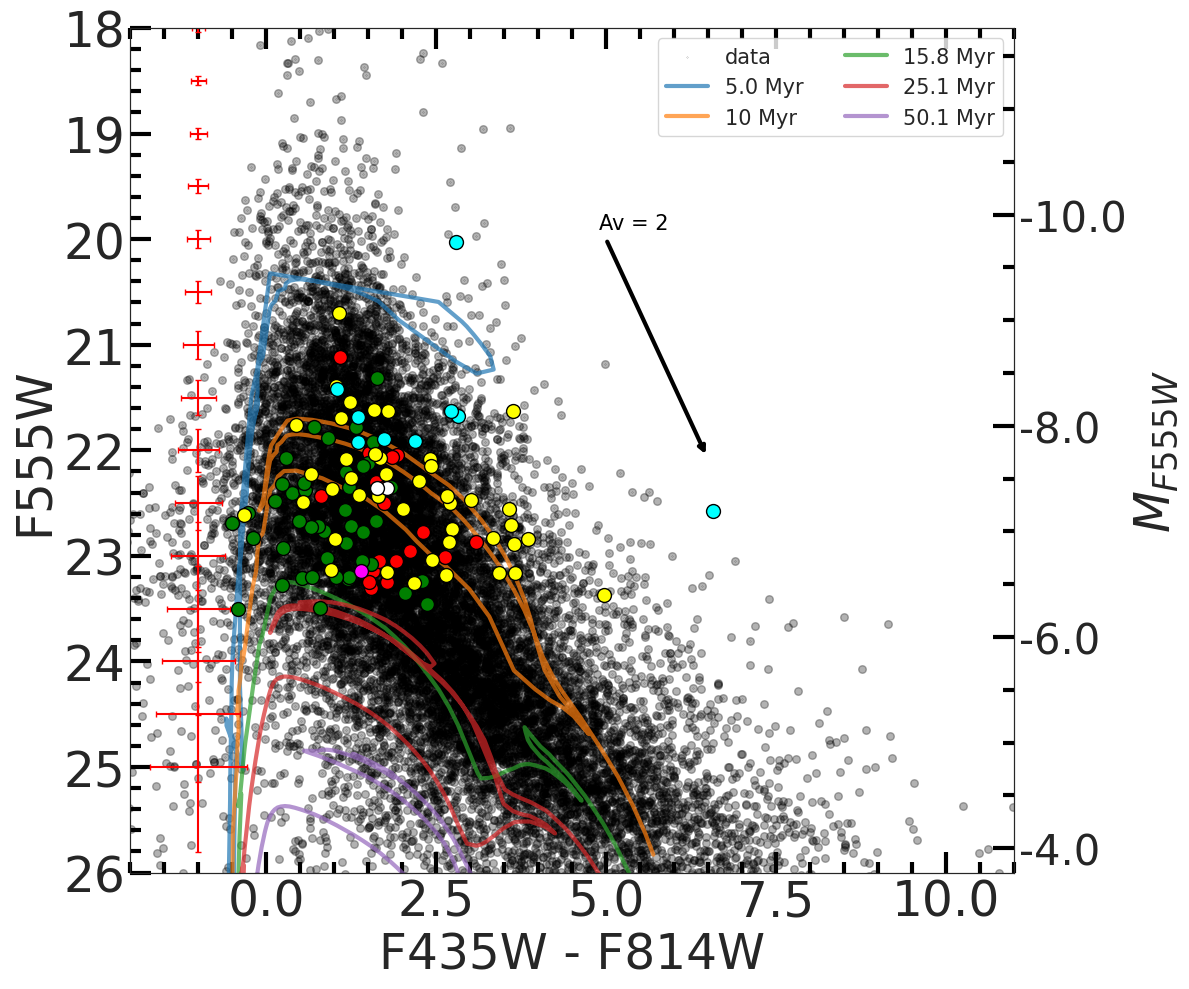

In [164]:
tab = tab_main

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f435w',
           'filt2':'f814w',
           'filt3':'f555w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 5,
              'Av_y': 20,
              'Av_' : 2}

axis_limits= {'xlims': [-2, 11], 
              'ylims': [18, 26]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.2, 7.4, 7.7,],
                   'iso_mask_lim' : 100}

error_settings = {'ref_xpos': -1,
                  'mag_err_lim':1}

plot_settings = {'s':0.01, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_acs,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': False},
                      fig=fig, ax=ax)

# RSG
tab_temp = tab_main
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=30, color='black' ,zorder=0, alpha=0.3)

# RSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='RSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=100, color='red' ,zorder=200, edgecolor='black')

#BSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='BSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=100, color='green' ,zorder=200, edgecolor='black')

#YSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='YSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=100, color='yellow' ,zorder=200, edgecolor='black')

#YMS
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='YMS']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=100, color='cyan' ,zorder=200, edgecolor='black')

#RRSG
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='RRSG']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']

ax.scatter(x,y, s=100, color='magenta' ,zorder=200, edgecolor='black')

#AGB
tab_temp = tab_sub_sel[tab_sub_sel['star_class']=='AGB']
x = tab_temp['mag_vega_F435W'] - tab_temp['mag_vega_F814W']
y = tab_temp['mag_vega_F555W']
ax.scatter(x,y, s=100, color='white' ,zorder=200, edgecolor='black')

In [22]:
hdul = fits.open("../data/M51/jw01783-o003_t009_nircam_clear-f335m/jw01783-o003_t009_nircam_clear-f335m_i2d.fits")

f335w = hdul[1].data
f335w_wcs = WCS(hdul[1].header)

Set DATE-AVG to '2023-06-14T18:26:43.490' from MJD-AVG.
Set DATE-END to '2023-06-14T19:02:31.470' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.938385 from OBSGEO-[XYZ].
Set OBSGEO-H to 1721146417.406 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [21]:
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry

In [24]:
coords_rsg = np.array([tab_fin_rsg['RA'].value, tab_fin_rsg['DEC'].value])
coords_bsg = np.array([tab_fin_bsg['RA'].value, tab_fin_bsg['DEC'].value])
coords_ysg = np.array([tab_fin_ysg['RA'].value, tab_fin_ysg['DEC'].value])
coords_yms = np.array([tab_fin_yms['RA'].value, tab_fin_yms['DEC'].value])

In [25]:
pos_rsg = f335w_wcs.world_to_pixel_values(coords_rsg.T)
pos_bsg = f335w_wcs.world_to_pixel_values(coords_bsg.T)
pos_ysg = f335w_wcs.world_to_pixel_values(coords_ysg.T)
pos_yms = f335w_wcs.world_to_pixel_values(coords_yms.T)

In [28]:
aps = [CircularAperture(pos_rsg, r=i) for i in [2,3,5,10]]

ap_pix = [ap.area for ap in aps]
# create circular annulus object
bags = CircularAnnulus(pos_rsg, r_in=10, r_out=15)

# count number of pixels within the annulus
sky_median = ApertureStats(f335w, bags).median

# perform aperture photometry on the data
phot_table = aperture_photometry(f335w, aps)

In [29]:
phot_table

id,xcenter,ycenter,aperture_sum_0,aperture_sum_1,aperture_sum_2,aperture_sum_3
int64,float64,float64,float64,float64,float64,float64
1,999.7982472834678,152.82114993046343,81.41249621598989,104.0840171300595,140.75682256638189,274.0971764882413
2,718.5743188507327,199.97823463749035,61.190125562850106,78.2520061486109,104.60211943868534,204.78601192689433
3,596.2722867711568,850.1430385330109,62.26448616108107,80.46779745508297,112.10198612477319,238.32215825637527
4,73.66542604835149,35.85598127800063,55.5200942765326,74.18145832893502,112.98548295368826,236.06404824843918
5,48.15588974353659,234.0293722933245,40.67192812584579,55.11513435045742,83.46788001800469,228.2423145643012
6,467.8597812695325,81.75626693459753,44.581642683805924,60.66173043602408,89.33395014542575,204.0073622646363
7,605.2101896667323,323.07871134994207,35.889707047547525,50.37976175393225,76.56867820560197,177.2985398796003
8,414.1114032620799,35.87519207431228,45.75017968464367,62.625987328428046,94.05289270902902,225.39087256465615
9,401.99992853609774,11.811328982744953,45.78765978813857,nan,nan,nan


In [40]:
# calculate source flux
for i in range(len(aps)):
    phot_table[f'flux_{i}'] = (phot_table[f'aperture_sum_{i}'].value - sky_median*ap_pix[i])

    phot_table[f'mag_{i}'] = -2.5 * np.log10(phot_table[f'flux_{i}'].value * hdul[1].header['PIXAR_SR']*1e6) - 23.95

    # calculate error on the source flux
    NE_2 =  phot_table[f'flux_{i}'].value + sky_median*ap_pix[i]
    
    phot_table[f'flux_err_{i}'] = np.sqrt(NE_2)


# # calculate signal to noise ratio
# phot_table['SNR'] = phot_table['flux']/phot_table['flux_err']

# phot_table['mag_err_F335M'] = 1.082/phot_table['SNR'].value

# phot_table = hstack([tab_fin_rsg, phot_table])

/tmp/ipykernel_578/3135647332.py:5: RuntimeWarning: invalid value encountered in log10
  phot_table[f'mag_{i}'] = -2.5 * np.log10(phot_table[f'flux_{i}'].value * hdul[1].header['PIXAR_SR']*1e6) - 23.95


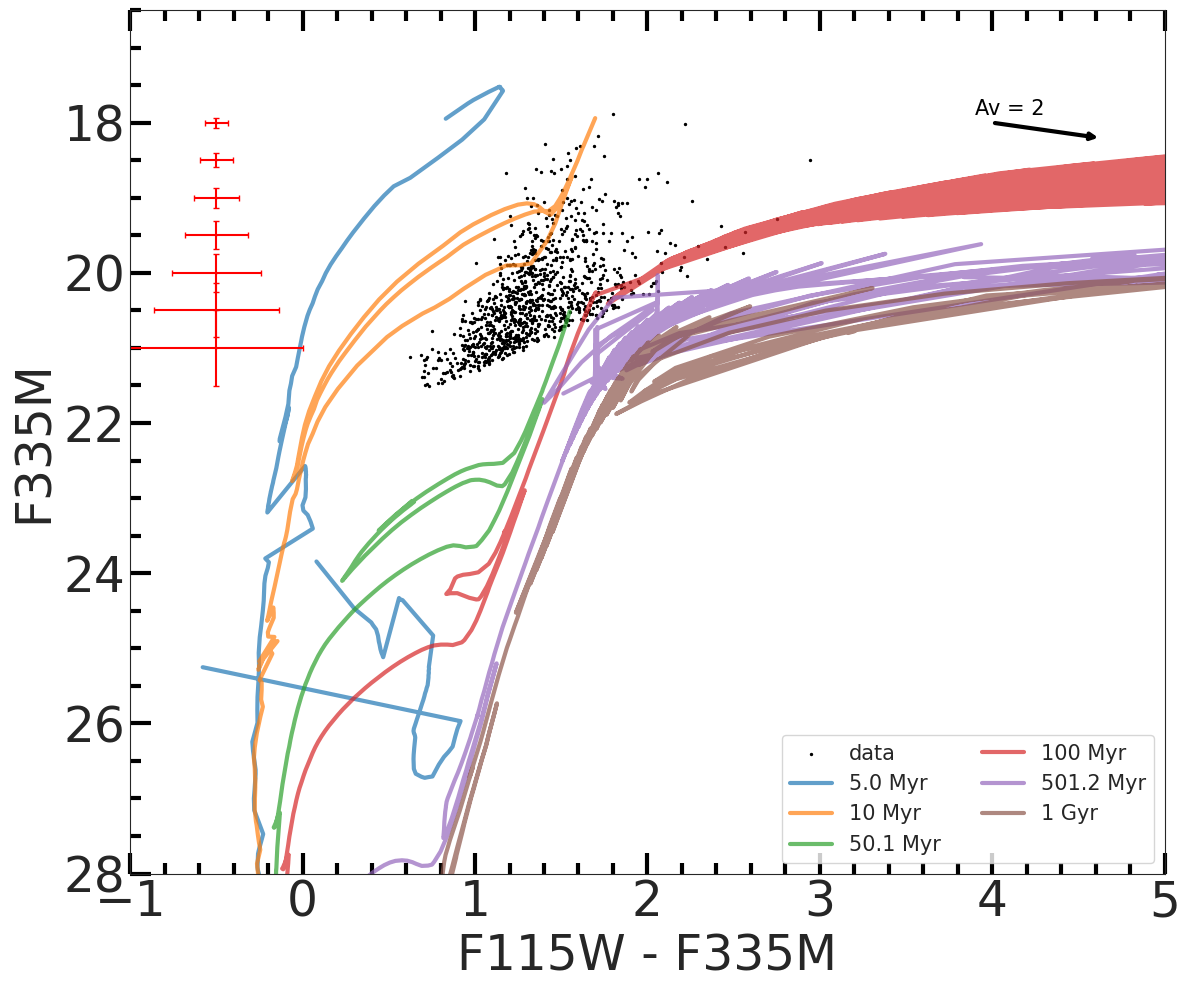

In [62]:
tab = phot_table
fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f115w',
           'filt2':'f335m',
           'filt3':'f335m'}

positions = {'ra_col' : 'RA',
             'dec_col': 'DEC',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-1, 5], 
              'ylims': [16.5, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 8,
                  'ages': [6.7, 7, 7.7, 8, 8.7,9]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.8}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]


#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')